# **CS 1810 Homework 4 Problem 1 — Understanding the Transformer**
---

This first section of the notebook contains the coding portions of the Transformer problem.

- **Part (d)**: Implement single-head self-attention from scratch (NumPy only)
- **Part (e)**: Multi-head attention + synthetic sequence classification (PyTorch) and attention visualization on the synthetic dataset

All random seeds are **fixed** so that results are fully reproducible.


## **Imports and Setup**

In [15]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Fix all random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# **Part (d): Single-Head Self-Attention (NumPy)**
---

Implement scaled dot-product self-attention using **only NumPy** (no PyTorch).

Given:
- $\mathbf{X} \in \mathbb{R}^{T \times d}$: input embeddings
- $\mathbf{W}_Q \in \mathbb{R}^{d \times d_k}$, $\mathbf{W}_K \in \mathbb{R}^{d \times d_k}$, $\mathbf{W}_V \in \mathbb{R}^{d \times d_v}$: weight matrices

Return:
- `output` $\in \mathbb{R}^{T \times d_v}$: the attention output
- `weights` $\in \mathbb{R}^{T \times T}$: the attention weight matrix $\mathbf{A}$

**Tip:** For numerical stability, subtract the row-wise max before applying softmax.

In [16]:
def self_attention(X, W_Q, W_K, W_V):
    """
    Single-head scaled dot-product self-attention.

    Args:
        X:   (T, d)   input embeddings
        W_Q: (d, d_k) query weight matrix
        W_K: (d, d_k) key weight matrix
        W_V: (d, d_v) value weight matrix

    Returns:
        output:  (T, d_v) attention output
        weights: (T, T)   attention weight matrix
    """
    # TODO: Implement self-attention.
    # 1. Compute Q, K, V by multiplying X with the weight matrices.
    # 2. Compute the raw score matrix S = Q @ K^T.
    # 3. Scale by 1 / sqrt(d_k).
    # 4. Apply numerically stable softmax row-wise.
    # 5. Multiply weights by V to get the output.

    Q = X @ W_Q
    K = X @ W_K
    V = X @ W_V

    S = Q @ K.T

    S = S / np.sqrt(W_Q.shape[1])

    S = np.exp(S - np.max(S, axis=1, keepdims=True))
    S = S / np.sum(S, axis=1, keepdims=True)

    attention = S @ V

    return attention, S

## **Verification: Updated Part (a) Hand Calculation**

This cell mirrors the revised 2-token hand-worked example from the written problem, with distinct $W_Q$, $W_K$, and $W_V$.


In [17]:
# Fixed input from the revised Part (a)
X_test_a = np.array([[1.0, 0.0],
                     [0.0, 1.0]])
W_Q_a = np.array([[1.0, 1.0],
                  [0.0, 1.0]])
W_K_a = np.array([[1.0, 0.0],
                  [1.0, 1.0]])
W_V_a = np.array([[2.0, 0.0],
                  [0.0, 1.0]])

Q_a = X_test_a @ W_Q_a
K_a = X_test_a @ W_K_a
V_a = X_test_a @ W_V_a
scores_a = Q_a @ K_a.T
scaled_scores_a = scores_a / np.sqrt(Q_a.shape[1])
output_a, weights_a = self_attention(X_test_a, W_Q_a, W_K_a, W_V_a)

print("Q:")
print(Q_a)
print("\nK:")
print(K_a)
print("\nV:")
print(V_a)
print("\nRaw scores S = QK^T:")
print(np.round(scores_a, 4))
print("\nScaled scores S / sqrt(d_k):")
print(np.round(scaled_scores_a, 4))
print("\nAttention weights A:")
print(np.round(weights_a, 4))


Q:
[[1. 1.]
 [0. 1.]]

K:
[[1. 0.]
 [1. 1.]]

V:
[[2. 0.]
 [0. 1.]]

Raw scores S = QK^T:
[[1. 2.]
 [0. 1.]]

Scaled scores S / sqrt(d_k):
[[0.7071 1.4142]
 [0.     0.7071]]

Attention weights A:
[[0.3302 0.6698]
 [0.3302 0.6698]]


## **Run Test Cases**

In [18]:
# Hidden hardcoded tests
def test_case_1():
    X = np.array([[2.0, -1.0, 0.5],
                  [0.0,  1.0, 1.5],
                  [-1.0, 2.0, 0.0]], dtype=float)
    W_Q = np.array([[1.0, 0.0],
                    [0.5, -1.0],
                    [1.5, 0.5]], dtype=float)
    W_K = np.array([[0.5, -1.0],
                    [1.0,  0.0],
                    [0.0,  2.0]], dtype=float)
    W_V = np.array([[1.0, 2.0],
                    [0.0, 1.0],
                    [-1.0, 0.5]], dtype=float)

    out, w = self_attention(X, W_Q, W_K, W_V)
    ref_out = np.array([[-1.35050652,  1.27824516],
             [-0.95543054,  0.53267847],
             [ 1.35107759,  3.06429131]])
    ref_w = np.array([[0.00428936, 0.72245985, 0.27325079],
                         [0.0573893,  0.19780757, 0.74480313],
                         [0.94108857, 0.00328768, 0.05562374]])

    assert np.allclose(out, ref_out, atol=1e-10)
    assert np.allclose(w, ref_w, atol=1e-10)
    print("  [PASS] test case 1")


def test_case_2():
    X = np.array([[1.0, 2.0],
                  [3.0, 4.0],
                  [5.0, 6.0],
                  [7.0, 8.0]], dtype=float)
    W_Q = np.array([[1.0, -2.0, 0.5],
                    [0.0,  1.0, 1.5]], dtype=float)
    W_K = np.array([[2.0, 0.0, -1.0],
                    [1.0, 1.0,  0.0]], dtype=float)
    W_V = np.array([[0.5, -1.0],
                    [1.5,  2.0]], dtype=float)

    out, w = self_attention(X, W_Q, W_K, W_V)
    ref_out = np.array([[6.85522256, 4.67761128],
                         [6.85522256, 4.67761128],
                         [6.85522256, 4.67761128],
                         [6.85522256, 4.67761128]])
    ref_w = np.array([[0.48698365, 0.27338479, 0.15347382, 0.08615774],
                     [0.48698365, 0.27338479, 0.15347382, 0.08615774],
                     [0.48698365, 0.27338479, 0.15347382, 0.08615774],
                     [0.48698365, 0.27338479, 0.15347382, 0.08615774]])

    assert np.allclose(out, ref_out, atol=1e-10)
    assert np.allclose(w, ref_w, atol=1e-10)
    print("  [PASS] test case 2")
    


# Run tests
test_case_1()
test_case_2()
print("\nAll self-attention tests passed!")



  [PASS] test case 1
  [PASS] test case 2

All self-attention tests passed!


# **Part (e): Multi-Head Attention**

Implement multi-head attention in PyTorch. Given $h$ heads, each head uses its own
$\mathbf{W}_Q^{(i)}, \mathbf{W}_K^{(i)} \in \mathbb{R}^{d \times d_k}$ and
$\mathbf{W}_V^{(i)} \in \mathbb{R}^{d \times d_v}$ where $d_k = d_v = d/h$.
The outputs are concatenated and projected through $\mathbf{W}_O$.

In [19]:
class MultiHeadAttention(nn.Module):
    """Multi-head scaled dot-product self-attention."""

    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        # TODO: Define W_Q, W_K, W_V, W_O as nn.Linear layers (no bias).
        # Each projects from d_model -> d_model. The head-splitting is done
        # via reshaping, not by having h separate small linear layers.

        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.W_O = nn.Linear(d_model, d_model, bias=False)

    def forward(self, X):
        """
        Args:
            X: (batch_size, seq_len, d_model)
        Returns:
            output:       (batch_size, seq_len, d_model)
            attn_weights: (batch_size, num_heads, seq_len, seq_len)
        """
        B, T, d = X.shape

        # TODO: Implement multi-head attention.
        # 1. Project X -> Q, K, V using the linear layers.
        # 2. Reshape to (B, num_heads, T, d_k) using .view and .transpose.
        # 3. Compute scaled dot-product attention for each head.
        # 4. Concatenate heads and project through W_O.

        Q = self.W_Q(X)
        K = self.W_K(X)
        V = self.W_V(X)

        Q = Q.view(B, T, self.num_heads, self.d_k).transpose(1, 2)
        K = K.view(B, T, self.num_heads, self.d_k).transpose(1, 2)
        V = V.view(B, T, self.num_heads, self.d_k).transpose(1, 2)

        S = Q @ K.transpose(-2, -1) / self.d_k ** 0.5
        A = torch.softmax(S, dim=-1)
        O_heads = A @ V

        O_concat = O_heads.transpose(1, 2).contiguous().view(B, T, d)
        O_proj = self.W_O(O_concat)

        return O_proj, A

### Test Multi-Head Attention

In [20]:
# Hidden hardcoded tests (deterministic, no details printed)
def mha_test_case_1():
    torch.manual_seed(7)
    d_model, num_heads = 8, 2
    mha = MultiHeadAttention(d_model, num_heads)

    with torch.no_grad():
        base = torch.arange(d_model * d_model, dtype=torch.float32).view(d_model, d_model)
        mha.W_Q.weight.copy_(0.01 * base)
        mha.W_K.weight.copy_(0.02 * base.flip(0))
        mha.W_V.weight.copy_(0.03 * base.flip(1))
        mha.W_O.weight.copy_(0.04 * torch.eye(d_model))

    X = torch.tensor([[[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0],
                       [1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0],
                       [2.0, 1.0, 0.0, 1.0, 2.0, 1.0, 0.0, 1.0]]], dtype=torch.float32)

    out, attn = mha(X)
    out = out.detach().numpy()
    attn = attn.detach().numpy()
    ref_out = np.array([[[0.0672    , 0.33599997, 0.6047999 , 0.8736    , 1.1423999 ,
        1.4111999 , 1.68      , 1.9487998 ],
       [0.0672    , 0.33599997, 0.6047999 , 0.8736    , 1.1423999 ,
        1.4111999 , 1.68      , 1.9487998 ],
       [0.0672    , 0.33599997, 0.6047999 , 0.8736    , 1.1423999 ,
        1.4111999 , 1.68      , 1.9487998 ]]])
    ref_attn = np.array([[[1.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [1.0000000e+00, 9.8455853e-12, 5.3755073e-10],
        [1.0000000e+00, 9.6935550e-23, 2.8896081e-19]],
       [[1.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [1.0000000e+00, 5.5979781e-13, 3.0563926e-11],
        [1.0000000e+00, 3.1337361e-25, 9.3415348e-22]]])

    assert np.allclose(out, ref_out, atol=1e-6)
    assert np.allclose(attn, ref_attn, atol=1e-6)
    print("  [PASS] test case 1")

def mha_test_case_2():
    torch.manual_seed(11)
    d_model, num_heads = 12, 3
    mha = MultiHeadAttention(d_model, num_heads)

    with torch.no_grad():
        eye = torch.eye(d_model)
        mha.W_Q.weight.copy_(eye)
        mha.W_K.weight.copy_(0.5 * eye)
        mha.W_V.weight.copy_(2.0 * eye)
        mha.W_O.weight.copy_(eye)

    X = torch.arange(2 * 4 * d_model, dtype=torch.float32).view(2, 4, d_model) / 10.0

    out, attn = mha(X)
    out = out.detach().numpy()
    attn = attn.detach().numpy()
    ref_out = np.array([[[4.1351027, 4.335103 , 4.535103 , 4.735103 , 6.170297 , 6.370297 ,
        6.5702972, 6.7702975, 7.7730255, 7.9730253, 8.173025 , 8.373025 ],
       [6.622606 , 6.822606 , 7.022606 , 7.222606 , 7.6672525, 7.8672523,
        8.067252 , 8.267253 , 8.603549 , 8.803549 , 9.003549 , 9.203548 ],
       [7.08198  , 7.2819805, 7.4819803, 7.6819806, 7.9282947, 8.128295 ,
        8.328295 , 8.5282955, 8.756126 , 8.956125 , 9.156125 , 9.356125 ],
       [7.173039 , 7.3730392, 7.573039 , 7.7730393, 7.983388 , 8.183388 ,
        8.383388 , 8.583388 , 8.789748 , 8.989748 , 9.189748 , 9.389748 ]],
         [[16.793667, 16.993668, 17.193668, 17.393667, 17.596087, 17.796085,
        17.996086, 18.196087, 18.397577, 18.597578, 18.797577, 18.997578],
       [16.798504, 16.998505, 17.198505, 17.398504, 17.599073, 17.799072,
        17.999073, 18.199074, 18.399427, 18.599428, 18.799427, 18.999428],
       [16.799644, 16.999645, 17.199646, 17.399647, 17.599781, 17.79978 ,
        17.99978 , 18.199781, 18.399862, 18.599863, 18.799862, 18.999863],
       [16.799915, 16.999916, 17.199917, 17.399916, 17.599947, 17.799946,
        17.999947, 18.199947, 18.39997 , 18.59997 , 18.799969, 18.99997 ]]])
    ref_attn = np.array([[[[1.87036365e-01, 2.23923162e-01, 2.68084705e-01, 3.20955664e-01],
        [6.22622482e-03, 3.14616710e-02, 1.58978656e-01, 8.03333402e-01],
        [9.82478668e-05, 2.09538592e-03, 4.46894839e-02, 9.53116953e-01],
        [1.35572918e-06, 1.22038844e-04, 1.09855868e-02, 9.88891006e-01]],

       [[7.18341470e-02, 1.38984129e-01, 2.68905491e-01, 5.20276248e-01],
        [1.61180040e-03, 1.31622348e-02, 1.07485034e-01, 8.77740979e-01],
        [2.37140794e-05, 8.17350810e-04, 2.81715766e-02, 9.70987439e-01],
        [3.22585862e-07, 4.69279585e-05, 6.82681939e-03, 9.93125916e-01]],

       [[2.24856213e-02, 7.03073218e-02, 2.19834775e-01, 6.87372327e-01],
        [4.02117614e-04, 5.30680129e-03, 7.00345784e-02, 9.24256444e-01],
        [5.68252153e-06, 3.16522259e-04, 1.76306646e-02, 9.82047081e-01],
        [7.66310322e-08, 1.80157767e-05, 4.23546275e-03, 9.95746434e-01]]],
      [[[1.8185647e-08, 6.9093526e-06, 2.6251059e-03, 9.9736804e-01],
        [2.4235319e-10, 3.8863476e-07, 6.2321138e-04, 9.9937648e-01],
        [3.2248108e-12, 2.1826366e-08, 1.4772658e-04, 9.9985230e-01],
        [4.2894453e-14, 1.2253593e-09, 3.5004519e-05, 9.9996495e-01]],

       [[4.3130082e-09, 2.6482010e-06, 1.6260006e-03, 9.9837142e-01],
        [5.7434040e-11, 1.4884158e-07, 3.8572474e-04, 9.9961412e-01],
        [7.6408834e-13, 8.3576071e-09, 9.1415939e-05, 9.9990857e-01],
        [1.0163037e-14, 4.6918630e-10, 2.1660515e-05, 9.9997830e-01]],

       [[1.0225062e-09, 1.0146086e-06, 1.0067682e-03, 9.9899215e-01],
        [1.3609688e-11, 5.6998605e-08, 2.3871531e-04, 9.9976128e-01],
        [1.8103960e-13, 3.2001826e-09, 5.6568228e-05, 9.9994338e-01],
        [2.4079290e-15, 1.7965043e-10, 1.3403335e-05, 9.9998665e-01]]]])

    assert np.allclose(out, ref_out, atol=1e-6)
    assert np.allclose(attn, ref_attn, atol=1e-6)
    print("  [PASS] test case 2")

# Run tests
mha_test_case_1()
mha_test_case_2()
print("\nAll multi-head attention tests passed!")



  [PASS] test case 1
  [PASS] test case 2

All multi-head attention tests passed!


# **Train a Transformer on a Synthetic Dataset**

We build a small synthetic sequence-classification task. Each sequence contains a `[CLS]` token, one `VAL0` or `VAL1`. The label is determined by that value token, while the other positions are distractor noise tokens.

This setup is useful because the model must learn to use attention to find the informative positions, and we can visualize what it attends to.


In [21]:
VOCAB = {
    "[PAD]": 0,
    "[CLS]": 1,
    "NOISE_A": 2,
    "NOISE_B": 3,
    "VAL0": 4,
    "VAL1": 5,
}
ID_TO_TOKEN = {idx: tok for tok, idx in VOCAB.items()}
SEQ_LEN = 6

def generate_synthetic_sequence(label, seq_len=SEQ_LEN):
    tokens = [VOCAB["[CLS]"]]
    content = np.random.choice([VOCAB["NOISE_A"], VOCAB["NOISE_B"]], size=seq_len - 1).tolist()
    key_pos = np.random.randint(1, seq_len - 1)
    # content[key_pos - 1] = VOCAB["KEY"]
    content[key_pos] = VOCAB["VAL1"] if label == 1 else VOCAB["VAL0"]
    return np.array(tokens + content, dtype=np.int64)

def make_synthetic_dataset(num_samples, seq_len=SEQ_LEN):
    X = np.zeros((num_samples, seq_len), dtype=np.int64)
    y = np.zeros(num_samples, dtype=np.int64)
    for i in range(num_samples):
        label = np.random.randint(0, 2)
        X[i] = generate_synthetic_sequence(label, seq_len=seq_len)
        y[i] = label
    return X, y

X_train_np, y_train_np = make_synthetic_dataset(4096)
X_test_np, y_test_np = make_synthetic_dataset(256)

train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train_np), torch.tensor(y_train_np)),
    batch_size=64,
    shuffle=True,
)
test_loader = DataLoader(
    TensorDataset(torch.tensor(X_test_np), torch.tensor(y_test_np)),
    batch_size=128,
    shuffle=False,
)

print("Example training sequence:")
example_tokens = [ID_TO_TOKEN[idx] for idx in X_train_np[0]]
print(example_tokens, "label=", int(y_train_np[0]))


Example training sequence:
['[CLS]', 'NOISE_B', 'VAL0', 'NOISE_A', 'NOISE_A', 'NOISE_B'] label= 0


In [26]:
class TinyTransformerClassifier(nn.Module):
    """Single-layer transformer encoder for synthetic sequence classification."""

    def __init__(self, vocab_size, d_model=32, num_heads=4, max_len=SEQ_LEN, num_classes=2):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.position_embedding = nn.Embedding(max_len, d_model)
        # TODO: Plug-in MultiHeadAttention you implemented
        self.attention = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, 2 * d_model),
            nn.ReLU(),
            nn.Linear(2 * d_model, d_model),
        )
        self.norm2 = nn.LayerNorm(d_model)
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, tokens):
        B, T = tokens.shape
        positions = torch.arange(T, device=tokens.device).unsqueeze(0).expand(B, T)
        h = self.token_embedding(tokens) + self.position_embedding(positions)
        attn_out, attn_weights = self.attention(h)
        h = self.norm1(h + attn_out)
        h = self.norm2(h + self.ffn(h))
        cls_repr = h[:, 0, :]
        logits = self.classifier(cls_repr)
        return logits, attn_weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TinyTransformerClassifier(vocab_size=len(VOCAB)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


Epoch 01 | train loss = 0.0000 | test acc = 1.0000
Epoch 02 | train loss = 0.0000 | test acc = 1.0000
Epoch 03 | train loss = 0.0000 | test acc = 1.0000
Epoch 04 | train loss = 0.0000 | test acc = 1.0000
Epoch 05 | train loss = 0.0000 | test acc = 1.0000
Epoch 06 | train loss = 0.0000 | test acc = 1.0000
Epoch 07 | train loss = 0.0000 | test acc = 1.0000
Epoch 08 | train loss = 0.0000 | test acc = 1.0000
Epoch 09 | train loss = 0.0000 | test acc = 1.0000
Epoch 10 | train loss = 0.0000 | test acc = 1.0000


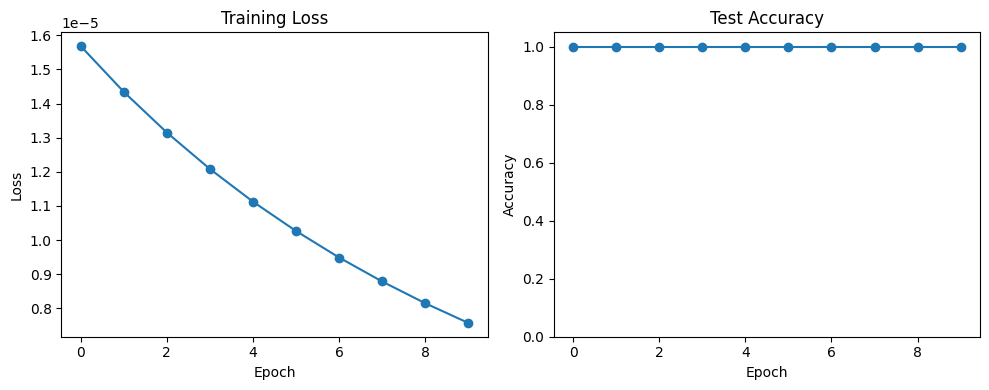

In [31]:
def evaluate_accuracy(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for tokens, labels in loader:
            tokens = tokens.to(device)
            labels = labels.to(device)
            logits, _ = model(tokens)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

num_epochs = 10
history = {"train_loss": [], "test_acc": []}

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for tokens, labels in train_loader:
        tokens = tokens.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits, _ = model(tokens)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)

    avg_train_loss = running_loss / len(train_loader.dataset)
    test_acc = evaluate_accuracy(model, test_loader, device)
    history["train_loss"].append(avg_train_loss)
    history["test_acc"].append(test_acc)
    print(f"Epoch {epoch + 1:02d} | train loss = {avg_train_loss:.4f} | test acc = {test_acc:.4f}")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], marker="o")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.plot(history["test_acc"], marker="o")
plt.title("Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0.0, 1.05)
plt.tight_layout()
plt.show()


## **Attention Heatmap**

We inspect one test sequence and plot the attention matrix for a single head. Looking at the `[CLS]` row is often the most useful view, since the classifier reads the `[CLS]` representation.


Sample tokens: ['[CLS]', 'NOISE_B', 'NOISE_A', 'VAL0', 'NOISE_B', 'NOISE_B']
True label: 0 | Predicted label: 0


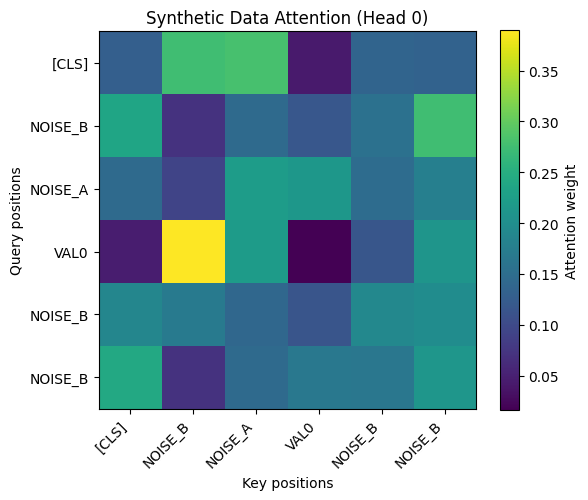

In [33]:
def plot_attention_heatmap(tokens, attn_weights, head=0, title="Attention Heatmap"):
    token_labels = [ID_TO_TOKEN[int(t)] for t in tokens]
    attn = attn_weights[head]

    plt.figure(figsize=(6, 5))
    plt.imshow(attn, cmap="viridis")
    plt.colorbar(label="Attention weight")
    plt.xticks(range(len(token_labels)), token_labels, rotation=45, ha="right")
    plt.yticks(range(len(token_labels)), token_labels)
    plt.xlabel("Key positions")
    plt.ylabel("Query positions")
    plt.title(title)
    plt.tight_layout()
    plt.savefig("img_output/1.5e.png")
    plt.show()

model.eval()
sample_tokens = torch.tensor(X_test_np[:1], device=device)
with torch.no_grad():
    sample_logits, sample_attn = model(sample_tokens)
sample_pred = int(sample_logits.argmax(dim=1).item())
sample_label = int(y_test_np[0])
decoded_tokens = [ID_TO_TOKEN[idx] for idx in X_test_np[0]]

print("Sample tokens:", decoded_tokens)
print(f"True label: {sample_label} | Predicted label: {sample_pred}")
plot_attention_heatmap(
    X_test_np[0],
    sample_attn[0].detach().cpu().numpy(),
    head=0,
    title="Synthetic Data Attention (Head 0)",
)


# **CS 1810 Homework 4 Problem 2 — Autoencoders**
---

This second section of the notebook contains the scaffolding coding portions of the autoencoder problem.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

In [ ]:
from datasets import load_dataset

print("Loading CelebA from HuggingFace...")
hf_full_train = load_dataset("tpremoli/CelebA-attrs", split="train")
hf_test = load_dataset("tpremoli/CelebA-attrs", split="test")

# Subsample training set for speed
TRAIN_SIZE = 30_000
hf_train = hf_full_train.select(range(TRAIN_SIZE))
print(f"Using {len(hf_train)} train (subsampled), {len(hf_test)} test images")

IMG_SIZE = 64

celeba_transform = transforms.Compose([
    transforms.CenterCrop(178),
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
])

class CelebADataset(Dataset):
    def __init__(self, hf_dataset, transform):
        self.data = hf_dataset
        self.transform = transform

    def __len__(self):
        pass
        # YOUR CODE HERE
        pass

    def __getitem__(self, idx):
        row = self.data[idx]
        img = self.transform(row["image"].convert("RGB"))
        smiling = row["Smiling"]
        glasses = row["Eyeglasses"]
        return img, smiling, glasses

BATCH_SIZE = 128
train_set = CelebADataset(hf_train, celeba_transform)
test_set = CelebADataset(hf_test, celeba_transform)

train_loader = DataLoader(
    train_set, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=4, pin_memory=True,
)
test_loader = DataLoader(
    test_set, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=4, pin_memory=True,
)

sample_img, sample_smile, sample_glasses = train_set[0]
print(f"Image shape: {sample_img.shape}, Smiling: {sample_smile}, Eyeglasses: {sample_glasses}")

In [ ]:
def show_images(images, title="", nrow=8):
    """Display a row of images."""
    images = images.detach().cpu().clamp(0, 1)
    n = min(len(images), nrow * 2)
    fig, axes = plt.subplots(1, n, figsize=(2.0 * n, 2.2))
    if n == 1:
        axes = [axes]
    for i in range(n):
        axes[i].imshow(images[i].permute(1, 2, 0).numpy())
        axes[i].axis("off")
    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

def show_paired(originals, reconstructions, n=5):
    """Originals (top) vs reconstructions (bottom)."""
    originals = originals.detach().cpu().clamp(0, 1)
    reconstructions = reconstructions.detach().cpu().clamp(0, 1)
    fig, axes = plt.subplots(2, n, figsize=(2.2 * n, 4.5))
    for i in range(n):
        axes[0, i].imshow(originals[i].permute(1, 2, 0).numpy())
        axes[0, i].axis("off")
        axes[1, i].imshow(reconstructions[i].permute(1, 2, 0).numpy())
        axes[1, i].axis("off")
    axes[0, 0].set_ylabel("Original", fontsize=11)
    axes[1, 0].set_ylabel("Recon", fontsize=11)
    plt.tight_layout()
    plt.show()

def plot_losses(losses, title="Training Loss", labels=None):
    if not isinstance(losses[0], (list, tuple)):
        losses = [losses]
        labels = [title]
    fig, ax = plt.subplots(figsize=(6, 3.5))
    for loss, label in zip(losses, labels):
        ax.plot(loss, label=label)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

## Part 1: The Autoencoder

Implement a convolutional autoencoder for CelebA ($3 \times 64 \times 64$).

**Architecture guide.**

- **Encoder:** 4 stride-2 `Conv2d` layers (channels $3 \to 32 \to 64 \to 128 \to 256$),
  each followed by `BatchNorm2d` + `ReLU`. Spatially: $64 \to 32 \to 16 \to 8 \to 4$.
  Flatten to $256 \times 4 \times 4 = 4096$, then `Linear(4096, 128)`.
- **Decoder:** Mirror with `ConvTranspose2d`. Final activation: `Sigmoid`.

In [ ]:
LATENT_DIM = 128

class Encoder(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        # YOUR CODE HERE
        pass

    def forward(self, x):
        # YOUR CODE HERE
        pass

class Decoder(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        # YOUR CODE HERE
        pass

    def forward(self, z):
        # YOUR CODE HERE
        pass
        pass

class Autoencoder(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.encoder =
        # YOUR CODE HERE
        pass
        self.decoder =
        # YOUR CODE HERE
        pass

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z

In [ ]:
NUM_EPOCHS_AE = 20

ae = Autoencoder().to(device)
ae_optimizer = torch.optim.Adam(ae.parameters(), lr=1e-3)
ae_train_losses = []
ae_test_losses = []

for epoch in range(NUM_EPOCHS_AE):
    # Train
    ae.train()
    total_loss = 0.0
    for x, _, _ in train_loader:
        # Classic training loop. Mind the tuple being returned from the AE, and choose the correct value to keep and operate on.
        # YOUR CODE HERE
        pass
    ae_train_losses.append(total_loss / len(train_loader.dataset))

    # Test
    ae.eval()
    test_loss = 0.0
    with torch.no_grad():
        for x, _, _ in test_loader:
            x = x.to(device)
            x_recon, _ = ae(x)
            test_loss += F.mse_loss(x_recon, x).item() * x.size(0)
    ae_test_losses.append(test_loss / len(test_loader.dataset))

    if (epoch + 1) % 5 == 0:
        print(
            f"AE Epoch {epoch+1}/{NUM_EPOCHS_AE}  "
            f"train={ae_train_losses[-1]:.5f}  test={ae_test_losses[-1]:.5f}"
        )

In [ ]:
plot_losses(
    [ae_train_losses, ae_test_losses],
    title="Standard AE: Train vs Test Loss",
    labels=["Train", "Test"],
)

### AE: Reconstructions and Random Samples

*(Answer question 1(b) in the written component after seeing these results.)*

In [ ]:
ae.eval()
test_batch = next(iter(test_loader))
test_x = test_batch[0].to(device)

with torch.no_grad():
    test_recon, _ = ae(test_x)
show_paired(test_x, test_recon, n=5)

# Sample from N(0, I) and decode
with torch.no_grad():
    z_random = torch.randn(10, LATENT_DIM).to(device)
    random_samples = ae.decoder(z_random)
show_images(random_samples, title="AE: Decoded samples from N(0, I)", nrow=10)

## Part 3: VAE Implementation

The VAE encoder shares the same convolutional backbone as the AE encoder, but
instead of one linear projection to $\mathbf{z}$, it has **two linear heads**
from the flattened features:

- `fc_mu` $\to \mu_\phi(\mathbf{x}) \in \mathbb{R}^d$
- `fc_logvar` $\to \log\sigma_\phi^2(\mathbf{x}) \in \mathbb{R}^d$

During training, sample $\mathbf{z} = \mu + \sigma \odot \epsilon$ with
$\epsilon \sim \mathcal{N}(0, I)$ (the reparameterization trick from Part 2).
The decoder is identical to Part 1.

In [ ]:
class VAEEncoder(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.conv = nn.Sequential(...)
        # YOUR CODE HERE
        pass
        self.fc_mu = nn.Linear(256 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(256 * 4 * 4, latent_dim)

    def forward(self, x):
        # YOUR CODE HERE
        pass
        return self.fc_mu(h), self.fc_logvar(h)

class VAE(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.encoder = VAEEncoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def reparameterize(self, mu, logvar):
        # YOUR CODE HERE
        pass
        return mu + std * eps

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

def vae_loss(x_recon, x, mu, logvar):
    """Negative ELBO = recon + KL. Returns (total, recon, kl)."""
    recon = F.mse_loss(x_recon, x, reduction="sum") / x.size(0)
    kl = -0.5 * torch.mean(
        torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
    )
    return recon + kl, recon, kl

In [ ]:
NUM_EPOCHS_VAE = 30

vae = VAE().to(device)
vae_optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)
vae_hist = {"train_total": [], "train_recon": [], "train_kl": [],
            "test_total": [], "test_recon": [], "test_kl": []}

for epoch in range(NUM_EPOCHS_VAE):
    # Train
    vae.train()
    t_total, t_recon, t_kl = 0.0, 0.0, 0.0
    for batch in train_loader:
        x = batch[0].to(device)
        x_recon, mu, logvar = vae(x)
        loss, rl, kl = vae_loss(x_recon, x, mu, logvar)
        vae_optimizer.zero_grad()
        loss.backward()
        vae_optimizer.step()
        t_total += loss.item() * x.size(0)
        t_recon += rl.item() * x.size(0)
        t_kl += kl.item() * x.size(0)
    n_train = len(train_loader.dataset)
    vae_hist["train_total"].append(t_total / n_train)
    vae_hist["train_recon"].append(t_recon / n_train)
    vae_hist["train_kl"].append(t_kl / n_train)

    # Test
    vae.eval()
    t_total, t_recon, t_kl = 0.0, 0.0, 0.0
    with torch.no_grad():
        for batch in test_loader:
            x = batch[0].to(device)
            x_recon, mu, logvar = vae(x)
            loss, rl, kl = vae_loss(x_recon, x, mu, logvar)
            t_total += loss.item() * x.size(0)
            t_recon += rl.item() * x.size(0)
            t_kl += kl.item() * x.size(0)
    n_test = len(test_loader.dataset)
    vae_hist["test_total"].append(t_total / n_test)
    vae_hist["test_recon"].append(t_recon / n_test)
    vae_hist["test_kl"].append(t_kl / n_test)

    if (epoch + 1) % 5 == 0:
        print(
            f"VAE Epoch {epoch+1}/{NUM_EPOCHS_VAE}  "
            f"train={vae_hist['train_total'][-1]:.4f}  "
            f"test={vae_hist['test_total'][-1]:.4f}  "
            f"recon={vae_hist['test_recon'][-1]:.4f}  "
            f"kl={vae_hist['test_kl'][-1]:.4f}"
        )

In [ ]:
plot_losses(
    [vae_hist["train_recon"], vae_hist["test_recon"]],
    title="VAE: Reconstruction Loss",
    labels=["Train", "Test"],
)
plot_losses(
    [vae_hist["train_kl"], vae_hist["test_kl"]],
    title="VAE: KL Divergence",
    labels=["Train", "Test"],
)
plot_losses(
    [vae_hist["train_total"], vae_hist["test_total"]],
    title="VAE: Total Loss (Neg. ELBO)",
    labels=["Train", "Test"],
)

### VAE: Reconstructions and Random Samples

*(Answer question 3(h) in the written component using these plots.)*

In [ ]:
vae.eval()
with torch.no_grad():
    vae_recon, _, _ = vae(test_x)
show_paired(test_x, vae_recon, n=5)

with torch.no_grad():
    z_sample = torch.randn(10, LATENT_DIM).to(device)
    vae_samples = vae.decoder(z_sample)
show_images(vae_samples, title="VAE: Decoded samples from N(0, I)", nrow=10)

## Part 4: Latent Arithmetic

We compute **attribute direction vectors** in latent space using CelebA's binary labels:

$$\mathbf{v}_{\text{attr}} = \bar{\mathbf{z}}_{\text{has attr}} - \bar{\mathbf{z}}_{\text{no attr}}$$

Adding or subtracting this vector from a face's latent code should toggle the attribute.

In [ ]:
def compute_attribute_vector(model, loader, attr_idx, is_vae=False):
    """Mean latent for attr=1 minus mean latent for attr=0."""
    sum_pos = torch.zeros(LATENT_DIM)
    sum_neg = torch.zeros(LATENT_DIM)
    n_pos, n_neg = 0, 0
    model.eval()
    with torch.no_grad():
        for batch in loader:
            x = batch[0].to(device)
            attr = batch[1 + attr_idx]
            if is_vae:
                mu, _ = model.encoder(x)
                z = mu.cpu()
            else:
                z = model.encoder(x).cpu()
            pos = attr == 1
            neg = attr == -1
            if pos.any():
                sum_pos +=
                n_pos +=
                # YOUR CODE HERE
                pass
            if neg.any():
                sum_neg += z[neg].sum(0)
                n_neg += neg.sum().item()
    return sum_pos / n_pos - sum_neg / n_neg

vae_smile_vec = compute_attribute_vector(vae, train_loader, 0, is_vae=True)
vae_glasses_vec = compute_attribute_vector(vae, train_loader, 1, is_vae=True)
ae_smile_vec = compute_attribute_vector(ae, train_loader, 0, is_vae=False)
ae_glasses_vec = compute_attribute_vector(ae, train_loader, 1, is_vae=False)

print(f"VAE — smile norm: {vae_smile_vec.norm():.2f}, glasses norm: {vae_glasses_vec.norm():.2f}")
print(f"AE  — smile norm: {ae_smile_vec.norm():.2f}, glasses norm: {ae_glasses_vec.norm():.2f}")


In [ ]:
def apply_attribute(model, test_imgs, attr_vec, attr_name, is_vae=False, scale=3.0):
    """3-row grid: −attr, original, +attr."""
    model.eval()
    n = min(6, len(test_imgs))
    x = test_imgs[:n].to(device)
    with torch.no_grad():
        if is_vae:
            mu, _ = model.encoder(x)
            z = mu
        else:
            z = model.encoder(x)
        v = attr_vec.to(z.device)
        recon_orig = model.decoder(z).cpu().clamp(0, 1)
        recon_add = model.decoder(z + scale * v).cpu().clamp(0, 1)
        recon_sub = model.decoder(z - scale * v).cpu().clamp(0, 1)

    tag = "VAE" if is_vae else "AE"
    fig, axes = plt.subplots(3, n, figsize=(2.2 * n, 6.5))
    for i in range(n):
        for row, img in enumerate([recon_sub, recon_orig, recon_add]):
            axes[row, i].imshow(img[i].permute(1, 2, 0).numpy())
            axes[row, i].axis("off")
    axes[0, 0].set_ylabel(f"- {attr_name}", fontsize=10)
    axes[1, 0].set_ylabel("Original", fontsize=10)
    axes[2, 0].set_ylabel(f"+ {attr_name}", fontsize=10)
    fig.suptitle(f"{tag}: {attr_name} (scale={scale})", fontsize=13)
    plt.tight_layout()
    plt.show()

test_imgs_attr = next(iter(test_loader))[0]

# VAE
apply_attribute(vae, test_imgs_attr, vae_smile_vec, "Smiling", is_vae=True)
apply_attribute(vae, test_imgs_attr, vae_glasses_vec, "Eyeglasses", is_vae=True)
# AE
apply_attribute(ae, test_imgs_attr, ae_smile_vec, "Smiling", is_vae=False)
apply_attribute(ae, test_imgs_attr, ae_glasses_vec, "Eyeglasses", is_vae=False)

In [ ]:
def interpolate_attribute(model, test_img, attr_vec, attr_name, n_steps=11, scale=4.0):
    """Sweep from −scale to +scale along attr direction."""
    model.eval()
    x = test_img.unsqueeze(0).to(device)
    with torch.no_grad():
        mu, _ = model.encoder(x)
        alphas = np.linspace(-scale, scale, n_steps)
        z_interp = torch.stack(
            [mu[0] + a * attr_vec.to(mu.device) for a in alphas]
        )
        imgs = model.decoder(z_interp).cpu().clamp(0, 1)

    fig, axes = plt.subplots(1, n_steps, figsize=(2.0 * n_steps, 2.4))
    for i, ax in enumerate(axes):
        ax.imshow(imgs[i].permute(1, 2, 0).numpy())
        ax.axis("off")
        if i == 0:
            ax.set_title(f"- {attr_name}", fontsize=9)
        elif i == n_steps - 1:
            ax.set_title(f"+ {attr_name}", fontsize=9)
    fig.suptitle(f"VAE: Interpolation along '{attr_name}'", fontsize=13)
    plt.tight_layout()
    plt.show()

face = test_imgs_attr[0]
interpolate_attribute(vae, face, vae_smile_vec, "Smiling")
interpolate_attribute(vae, face, vae_glasses_vec, "Eyeglasses")